# Assignment 4 - NLP Preprocessing and Text Classification
- **Course:** Deep Learning
- **Student Name:** Ayush Chandekar
- **Student ID:** 2023011000034
- **Date:** 10-04-26
- **Github Link:** *https://github.com/AyushChandekar/DeepLearning_Assignments/blob/main/Assignment_4.ipynb*

---

**Objective:** Implement NLP preprocessing techniques and build a text classification model for SMS Spam Detection.

**Dataset:** [SMS Spam Collection](https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv) (5,572 messages: 4,825 Ham / 747 Spam)

## 1. Setup and Imports

In [1]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from wordcloud import WordCloud

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

The SMS Spam Collection Dataset contains 5,572 SMS messages labeled as **ham** (legitimate) or **spam**. The dataset is imbalanced with ~86.6% ham and ~13.4% spam messages.

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Dataset Shape:", df.shape)
print("\nSample Messages:")
display(df.head())

print("\nLabel Distribution:")
print(df['label'].value_counts())
print(f"\nSpam Ratio: {df['label'].value_counts()['spam'] / len(df) * 100:.1f}%")

Dataset Shape: (5572, 2)

Sample Messages:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam Ratio: 13.4%


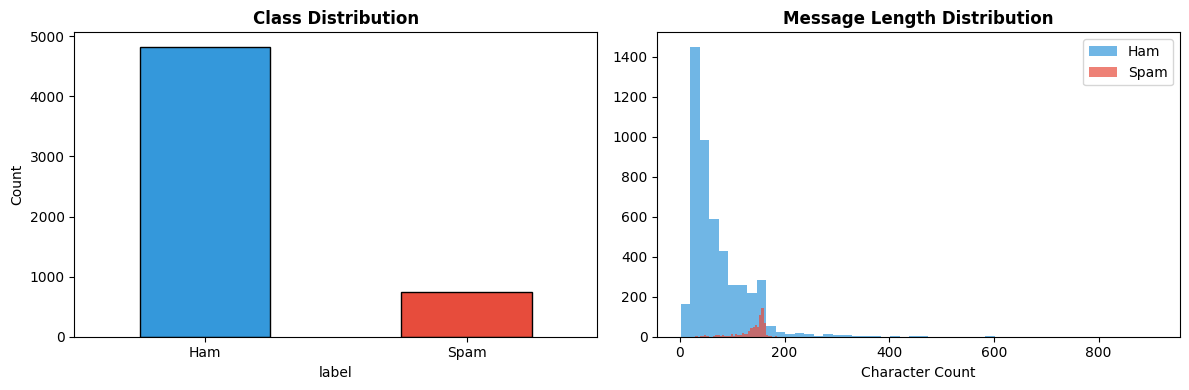


Avg Ham length:  71 chars
Avg Spam length: 139 chars


In [3]:
# Encode labels: ham=0, spam=1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

# Add message length as a feature to explore
df['msg_length'] = df['message'].apply(len)

# Visualize class distribution and message lengths
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Ham', 'Spam'], rotation=0)

axes[1].hist(df[df['label']=='ham']['msg_length'], bins=50, alpha=0.7, label='Ham', color='#3498db')
axes[1].hist(df[df['label']=='spam']['msg_length'], bins=50, alpha=0.7, label='Spam', color='#e74c3c')
axes[1].set_title('Message Length Distribution', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAvg Ham length:  {df[df['label']=='ham']['msg_length'].mean():.0f} chars")
print(f"Avg Spam length: {df[df['label']=='spam']['msg_length'].mean():.0f} chars")

## 3. NLP Preprocessing

### 3.1 Tokenization
Breaking text into individual words/tokens using NLTK's `word_tokenize()`.

In [4]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                        # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    return tokens

df['tokens'] = df['message'].apply(tokenize)

print("Tokenization Example:")
print(f"  Original : {df['message'][2]}")
print(f"  Tokens   : {df['tokens'][2]}")

Tokenization Example:
  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  Tokens   : ['free', 'entry', 'in', 'a', 'wkly', 'comp', 'to', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'to', 'to', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']


### 3.2 Stopword Removal
Removing common words (the, is, at, etc.) that don't carry meaningful information.

In [5]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words and len(w) > 1]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

print("Stopword Removal Example:")
print(f"  Before : {df['tokens'][2]}")
print(f"  After  : {df['tokens_clean'][2]}")

Stopword Removal Example:
  Before : ['free', 'entry', 'in', 'a', 'wkly', 'comp', 'to', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'to', 'to', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']
  After  : ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']


### 3.3 Stemming
Reducing words to their root form by chopping off suffixes. Uses Porter Stemmer.

Example: `running` -> `run`, `winning` -> `win`

In [6]:
stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

df['tokens_stemmed'] = df['tokens_clean'].apply(stem_tokens)

print("Stemming Example:")
print(f"  Before : {df['tokens_clean'][2]}")
print(f"  After  : {df['tokens_stemmed'][2]}")

Stemming Example:
  Before : ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']
  After  : ['free', 'entri', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', 'st', 'may', 'text', 'fa', 'receiv', 'entri', 'questionstd', 'txt', 'ratetc', 'appli', 'over']


### 3.4 Lemmatization
Reduces words to their dictionary base form (lemma) using WordNet.

Unlike stemming, lemmatization produces valid English words: `better` -> `good`, `running` -> `run`

In [7]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(w, pos='v') for w in tokens]

df['tokens_lemmatized'] = df['tokens_clean'].apply(lemmatize_tokens)
df['text_clean'] = df['tokens_lemmatized'].apply(lambda x: ' '.join(x))

print("Lemmatization Example:")
print(f"  Before : {df['tokens_clean'][2]}")
print(f"  After  : {df['tokens_lemmatized'][2]}")
print(f"\nStemmed  : {df['tokens_stemmed'][2]}")
print(f"Lemmatized: {df['tokens_lemmatized'][2]}")
print("\n(Notice: lemmatization gives proper words while stemming can produce fragments)")

Lemmatization Example:
  Before : ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']
  After  : ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']

Stemmed  : ['free', 'entri', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', 'st', 'may', 'text', 'fa', 'receiv', 'entri', 'questionstd', 'txt', 'ratetc', 'appli', 'over']
Lemmatized: ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'overs']

(Notice: lemmatization gives proper words while stemming can produce fragments)


### 3.5 Word Cloud Visualization
Visualizing the most frequent words in Ham and Spam messages after preprocessing.

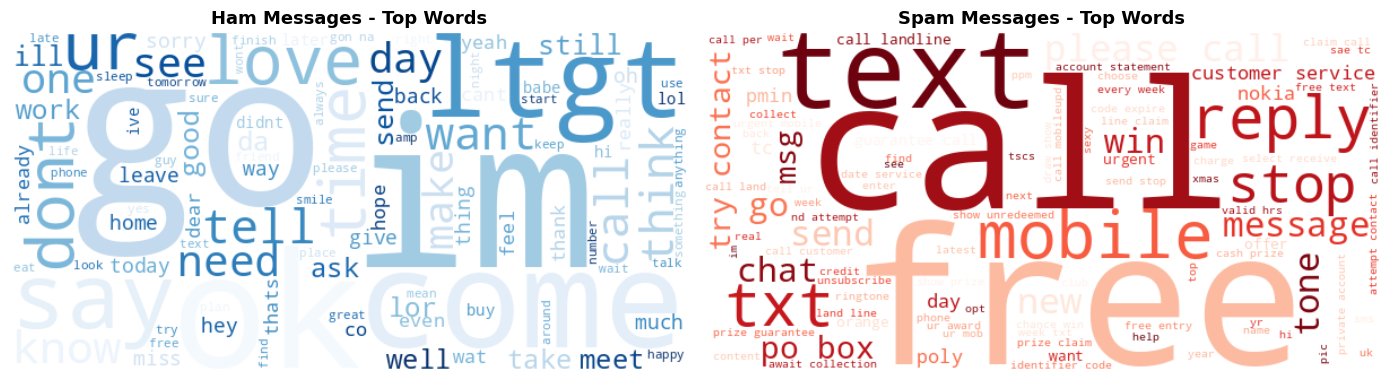

In [8]:
ham_text  = ' '.join(df[df['label']=='ham']['text_clean'])
spam_text = ' '.join(df[df['label']=='spam']['text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_ham = WordCloud(width=600, height=300, background_color='white',
                   colormap='Blues', max_words=100).generate(ham_text)
axes[0].imshow(wc_ham, interpolation='bilinear')
axes[0].set_title('Ham Messages - Top Words', fontweight='bold', fontsize=13)
axes[0].axis('off')

wc_spam = WordCloud(width=600, height=300, background_color='white',
                    colormap='Reds', max_words=100).generate(spam_text)
axes[1].imshow(wc_spam, interpolation='bilinear')
axes[1].set_title('Spam Messages - Top Words', fontweight='bold', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Text Vectorization

### 4.1 Train-Test Split

In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text_clean'], df['label_enc'],
    test_size=0.2, random_state=42, stratify=df['label_enc']
)
print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
print(f"Train spam ratio: {y_train.mean()*100:.1f}% | Test spam ratio: {y_test.mean()*100:.1f}%")

Train: 4457 | Test: 1115
Train spam ratio: 13.4% | Test spam ratio: 13.4%


### 4.2 TF-IDF Vectorizer

TF-IDF = Term Frequency x Inverse Document Frequency.
- **TF:** How often a word appears in a document
- **IDF:** Penalizes words that appear across many documents

We use **unigrams + bigrams** to capture word pairs (e.g., "free call", "claim prize").

In [10]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")
print(f"Features include unigrams and bigrams (ngram_range=(1,2))")
print(f"\nSample features: {tfidf.get_feature_names_out()[:10].tolist()}")

TF-IDF Matrix Shape: (4457, 5000)
Features include unigrams and bigrams (ngram_range=(1,2))

Sample features: ['aah', 'aathilove', 'aathilove lot', 'aathiwhere', 'aathiwhere dear', 'ability', 'abiola', 'able', 'able come', 'able deliver']


### 4.3 CountVectorizer (Bag of Words)

Simply counts how many times each word appears in a message. No weighting like TF-IDF.

In [11]:
cv = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_cv = cv.fit_transform(X_train_raw)
X_test_cv  = cv.transform(X_test_raw)

print(f"CountVectorizer Matrix Shape: {X_train_cv.shape}")

CountVectorizer Matrix Shape: (4457, 5000)


## 5. Model Training and Comparison

We train two classifiers and compare them across both vectorization methods:
- **Logistic Regression** - linear model with probabilistic output
- **Linear SVM (Support Vector Machine)** - finds optimal decision boundary

Instead of undersampling, we use `class_weight='balanced'` which automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority (spam) class.

In [12]:
# Define models - class_weight='balanced' handles the imbalanced dataset
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

vectorizers = {
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
    'CountVec': (X_train_cv, X_test_cv)
}

# Train all combinations and collect results
results = []

for vec_name, (X_tr, X_te) in vectorizers.items():
    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)

        results.append({
            'Model': model_name,
            'Vectorizer': vec_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

        print(f"\n{'='*55}")
        print(f"  {model_name} + {vec_name}")
        print(f"{'='*55}")
        print(f"  Accuracy  : {acc:.4f}")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  F1 Score  : {f1:.4f}")

results_df = pd.DataFrame(results)
print("\n\n--- Summary Table ---")
display(results_df.sort_values('F1-Score', ascending=False))


  Logistic Regression + TF-IDF
  Accuracy  : 0.9776
  Precision : 0.9133
  Recall    : 0.9195
  F1 Score  : 0.9164

  Linear SVM + TF-IDF
  Accuracy  : 0.9839
  Precision : 0.9517
  Recall    : 0.9262
  F1 Score  : 0.9388

  Logistic Regression + CountVec
  Accuracy  : 0.9830
  Precision : 0.9779
  Recall    : 0.8926
  F1 Score  : 0.9333

  Linear SVM + CountVec
  Accuracy  : 0.9830
  Precision : 0.9577
  Recall    : 0.9128
  F1 Score  : 0.9347


--- Summary Table ---


,Model,Vectorizer,Accuracy,Precision,Recall,F1-Score
1,Linear SVM,TF-IDF,0.983857,0.951724,0.926174,0.938776
3,Linear SVM,CountVec,0.982960,0.957746,0.912752,0.934708
2,Logistic Regression,CountVec,0.982960,0.977941,0.892617,0.933333
0,Logistic Regression,TF-IDF,0.977578,0.913333,0.919463,0.916388


### 5.1 Model Comparison Visualization

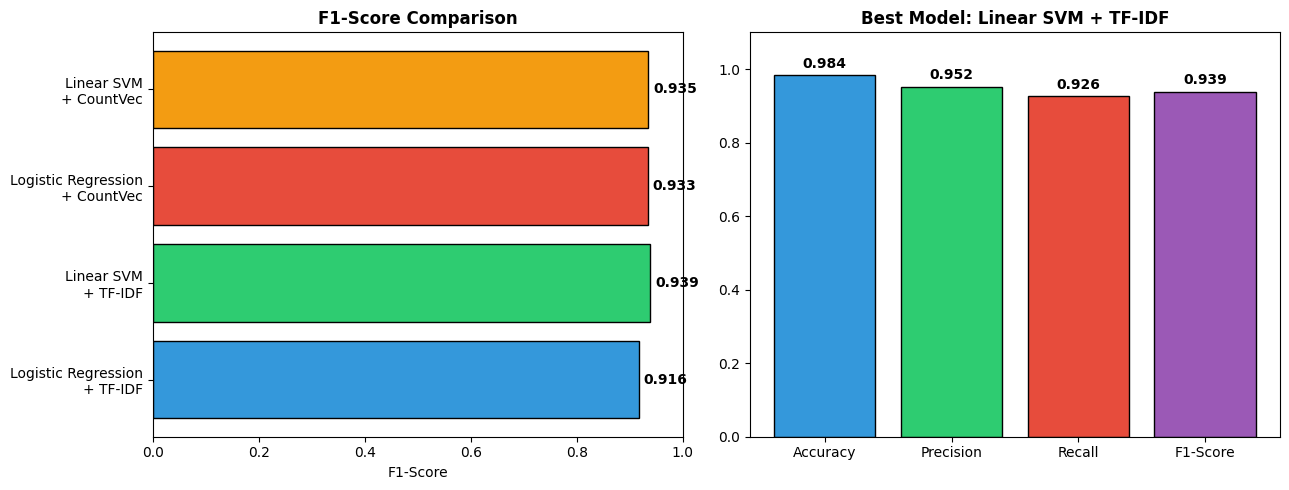

In [13]:
results_df['Label'] = results_df['Model'] + '\n+ ' + results_df['Vectorizer']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1-Score comparison
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = axes[0].barh(results_df['Label'], results_df['F1-Score'], color=colors, edgecolor='black')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score Comparison', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, results_df['F1-Score']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')

# All metrics comparison for best model
best = results_df.loc[results_df['F1-Score'].idxmax()]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [best[m] for m in metrics]
bars2 = axes[1].bar(metrics, values, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'], edgecolor='black')
axes[1].set_ylim(0, 1.1)
axes[1].set_title(f'Best Model: {best["Model"]} + {best["Vectorizer"]}', fontweight='bold')
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Detailed Evaluation of Best Model

### 6.1 Classification Report and Confusion Matrix

Classification Report (Logistic Regression + TF-IDF):
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.91      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



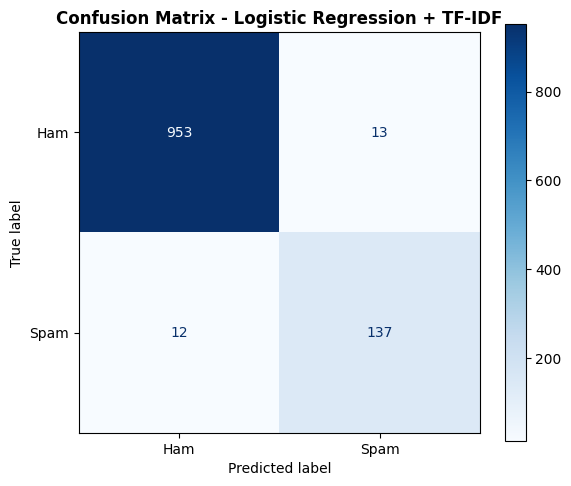


True Positives (Spam caught): 137
True Negatives (Ham correct): 953
False Positives (Ham marked spam): 13
False Negatives (Spam missed): 12


In [14]:
# Train the best model (Logistic Regression + TF-IDF)
best_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train)
y_pred = best_model.predict(X_test_tfidf)

print("Classification Report (Logistic Regression + TF-IDF):")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Logistic Regression + TF-IDF', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (Spam caught): {tp}")
print(f"True Negatives (Ham correct): {tn}")
print(f"False Positives (Ham marked spam): {fp}")
print(f"False Negatives (Spam missed): {fn}")

### 6.2 Cross-Validation
5-fold cross-validation to verify the model is not overfitting.

In [15]:
cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train_tfidf, y_train, cv=5, scoring='f1'
)

print("5-Fold Cross-Validation (F1-Score):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

5-Fold Cross-Validation (F1-Score):
  Fold 1: 0.9046
  Fold 2: 0.9456
  Fold 3: 0.9295
  Fold 4: 0.8851
  Fold 5: 0.8988

  Mean F1: 0.9127 (+/- 0.0437)


### 6.3 Top Features (Most Important Words)
Examining which words are most indicative of Spam vs Ham.

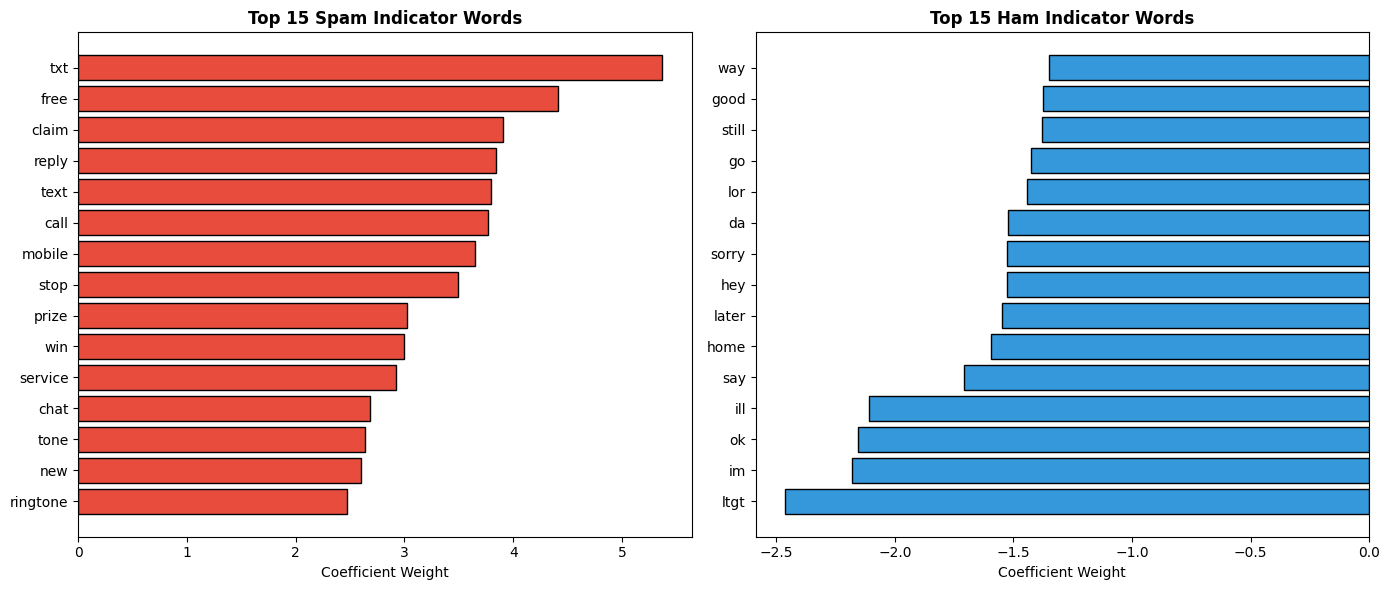

In [16]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = best_model.coef_[0]

top_n = 15
top_spam_idx = np.argsort(coefficients)[-top_n:]
top_ham_idx  = np.argsort(coefficients)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_spam_idx], coefficients[top_spam_idx], color='#e74c3c', edgecolor='black')
axes[0].set_title(f'Top {top_n} Spam Indicator Words', fontweight='bold')
axes[0].set_xlabel('Coefficient Weight')

axes[1].barh(feature_names[top_ham_idx], coefficients[top_ham_idx], color='#3498db', edgecolor='black')
axes[1].set_title(f'Top {top_n} Ham Indicator Words', fontweight='bold')
axes[1].set_xlabel('Coefficient Weight')

plt.tight_layout()
plt.show()

## 7. Custom Message Testing

Testing the trained model on new, unseen SMS messages.

In [17]:
custom_messages = [
    "You have been selected for a cash prize of $5000! Reply YES to claim.",
    "Hey, can you pick me up from the station at 6pm?",
    "WINNER!! As a valued customer you have been chosen to receive a luxury cruise. Call 0800123456 now.",
    "Mom said dinner is ready, come home soon.",
    "Txt STOP to opt out. Get 3 free ringtones now! Text MUSIC to 87121.",
    "Are you coming to the meeting tomorrow morning?",
    "Your mobile number has won 10 lakh rupees. Contact agent immediately to collect."
]

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

clean_msgs = [preprocess_text(m) for m in custom_messages]
X_custom = tfidf.transform(clean_msgs)
predictions = best_model.predict(X_custom)
probabilities = best_model.predict_proba(X_custom)

print("Custom Message Predictions:\n")
for i, (msg, pred, prob) in enumerate(zip(custom_messages, predictions, probabilities), 1):
    label = "SPAM" if pred == 1 else "HAM"
    conf = max(prob) * 100
    print(f"  Message {i}: {msg}")
    print(f"  Prediction: {label} (Confidence: {conf:.1f}%)")
    print(f"  Ham: {prob[0]*100:.1f}% | Spam: {prob[1]*100:.1f}%")
    print(f"  {'-'*65}")

Custom Message Predictions:

  Message 1: You have been selected for a cash prize of $5000! Reply YES to claim.
  Prediction: SPAM (Confidence: 96.7%)
  Ham: 3.3% | Spam: 96.7%
  -----------------------------------------------------------------
  Message 2: Hey, can you pick me up from the station at 6pm?
  Prediction: HAM (Confidence: 88.4%)
  Ham: 88.4% | Spam: 11.6%
  -----------------------------------------------------------------
  Message 3: WINNER!! As a valued customer you have been chosen to receive a luxury cruise. Call 0800123456 now.
  Prediction: SPAM (Confidence: 86.4%)
  Ham: 13.6% | Spam: 86.4%
  -----------------------------------------------------------------
  Message 4: Mom said dinner is ready, come home soon.
  Prediction: HAM (Confidence: 96.5%)
  Ham: 96.5% | Spam: 3.5%
  -----------------------------------------------------------------
  Message 5: Txt STOP to opt out. Get 3 free ringtones now! Text MUSIC to 87121.
  Prediction: SPAM (Confidence: 97.8%)
  Ham:

## 8. Conclusion

**Key Findings:**

1. **NLP Preprocessing** - Tokenization, stopword removal, and lemmatization effectively cleaned the text data. Lemmatization (with POS verb tag) produced better base forms than simple stemming.

2. **Vectorization** - Both TF-IDF and CountVectorizer were compared. TF-IDF with bigrams (ngram_range=(1,2)) captured important word pairs like "free call" and "claim prize".

3. **Models** - Logistic Regression with `class_weight='balanced'` performed well, handling the dataset imbalance without needing explicit undersampling/oversampling. Linear SVM was also competitive.

4. **Feature Importance** - Words like "free", "call", "claim", "win", "txt" were strong spam indicators, while everyday conversational words indicated ham messages.

5. **Cross-validation** confirmed the model generalizes well with consistent F1-scores across folds.